In [96]:

import cv2
import numpy as np
from scipy.stats import skew
from matplotlib import pyplot as plt
from pathlib import Path
import cv2

def metricas(imagen):

    datos = imagen.flatten().astype(np.float64)

    media = np.mean(datos)
    std = np.std(datos)

    # Energía
    energia = np.mean(datos**2)

    # Asimetría robusta
    if std < 1e-8:
        asimetria = 0.0
    else:
        momento3 = np.mean((datos - media)**3)
        asimetria = momento3 / (std**3)

    return std, asimetria, energia

def extraer_descriptores(lista_imagenes, kernel_A, kernel_B, kernel_C, n=60):
    
    descriptores = []

    for imagen in lista_imagenes[:n]:

        if imagen is None:
            continue

        # Convertir a escala de grises
        imagen_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

        # Aplicar filtros
        imagen_F1 = cv2.filter2D(imagen_gray, cv2.CV_64F, kernel_A)
        imagen_F2 = cv2.filter2D(imagen_gray, cv2.CV_64F, kernel_B)
        imagen_F3 = cv2.filter2D(imagen_gray, cv2.CV_64F, kernel_C)

        # Calcular métricas
        # std, asimetria, energia
        s1, a1, e1 = metricas(imagen_F1)
        s2, a2, e2 = metricas(imagen_F2)
        s3, a3, e3 = metricas(imagen_F3)

        # Promedio de los filtros
        e = (e1 + e2 + e3) / 3
        s = (s1 + s2 + s3) / 3
        a = (a1 + a2 + a3) / 3

        descriptores.append([e, s, a])

    return descriptores

kernel_sobel_v = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

kernel_sobel_h = np.array([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1]
], dtype=np.float32)

kernel_laplaciano = np.array([
    [ 0, -1,  0],
    [-1,  4, -1],
    [ 0, -1,  0]
], dtype=np.float32)




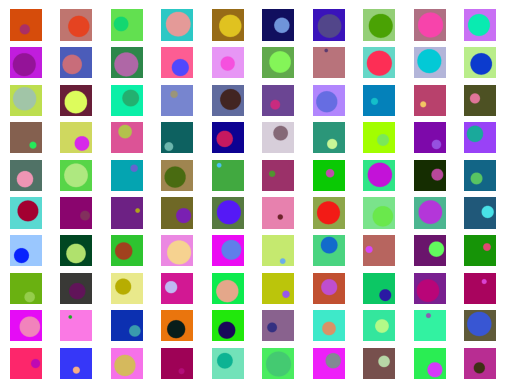

In [97]:
imagen_C = []

for i in range(1,101):
    carpeta = Path("Base_datos") / "C"
    ruta = carpeta / f"C ({i}).png"   
    imagen = cv2.imread(ruta)
    
    imagen_C.append(imagen)
    
    plt.subplot(10, 10, i)
    plt.imshow(imagen)
    plt.axis("off")

plt.show()  

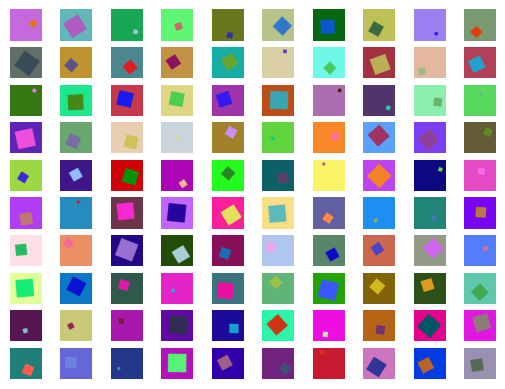

In [98]:

imagen_S = []

for i in range(1,101):
    carpeta = Path("Base_datos") / "S"
    ruta = carpeta / f"S ({i}).png"   
    imagen = cv2.imread(ruta)

    imagen_S.append(imagen)

    plt.subplot(10, 10, i)
    plt.imshow(imagen)
    plt.axis("off")

plt.show()  

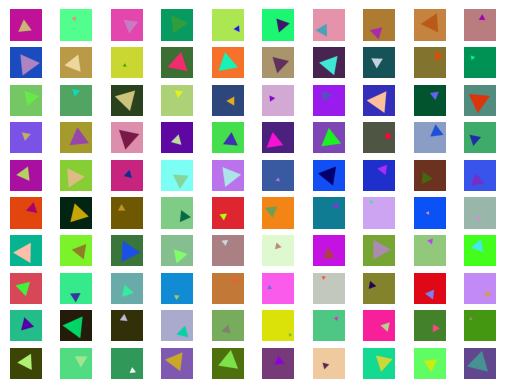

In [99]:

imagen_T = []

for i in range(1,101):
    carpeta = Path("Base_datos") / "T"
    ruta = carpeta / f"T ({i}).png"   
    imagen = cv2.imread(ruta)
    
    imagen_T.append(imagen)
    
    plt.subplot(10, 10, i)
    plt.imshow(imagen)
    plt.axis("off")

plt.show()  

In [100]:

from sklearn.preprocessing import StandardScaler

descriptores_C = extraer_descriptores(imagen_C, kernel_sobel_v, kernel_sobel_h, kernel_laplaciano)
descriptores_S = extraer_descriptores(imagen_S, kernel_sobel_v, kernel_sobel_h, kernel_laplaciano)
descriptores_T = extraer_descriptores(imagen_T, kernel_sobel_v, kernel_sobel_h, kernel_laplaciano)

print(np.array(descriptores_C).shape)  # (60,3)
print(np.array(descriptores_S).shape)  # (60,3)
print(np.array(descriptores_T).shape)  # (60,3)     

centro_c = np.mean(descriptores_C, axis=0)
centro_s = np.mean(descriptores_S, axis=0)
centro_t = np.mean(descriptores_T, axis=0)

print("Centroides originales:")

print("Centroide C:", centro_c)
print("Centroide S:", centro_s)
print("Centroide T:", centro_t) 

X_total = np.vstack((descriptores_C,
                     descriptores_S,
                     descriptores_T))

scaler = StandardScaler()
X_total = scaler.fit_transform(X_total)

print(np.array(X_total).shape)  # (180,1)

centro_c = np.mean(X_total[0:60], axis=0)
centro_s = np.mean(X_total[60:120], axis=0)
centro_t = np.mean(X_total[120:180], axis=0)

print("Centroides normalizados:")

print("Centroide C:", centro_c)
print("Centroide S:", centro_s)
print("Centroide T:", centro_t) 

(60, 3)
(60, 3)
(60, 3)
Centroides originales:
Centroide C: [3.75632885e+02 1.40857201e+01 2.18875163e-03]
Centroide S: [ 2.74092050e+02  1.32470637e+01 -4.53610810e-02]
Centroide T: [3.42293895e+02 1.39351090e+01 2.13161153e-01]
(180, 3)
Centroides normalizados:
Centroide C: [ 0.08994299  0.03025207 -0.03611791]
Centroide S: [-0.11319086 -0.04668696 -0.06764477]
Centroide T: [0.02324788 0.01643489 0.10376268]


In [101]:

def descriptor_individual(imagen, kernel_A, kernel_B, kernel_C):

    imagen_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

    F1 = cv2.filter2D(imagen_gray, cv2.CV_64F, kernel_A)
    F2 = cv2.filter2D(imagen_gray, cv2.CV_64F, kernel_B)
    F3 = cv2.filter2D(imagen_gray, cv2.CV_64F, kernel_C)

    s1, a1, e1 = metricas(F1)
    s2, a2, e2 = metricas(F2)
    s3, a3, e3 = metricas(F3)

    s = (s1 + s2 + s3) / 3
    a = (a1 + a2 + a3) / 3
    e = (e1 + e2 + e3) / 3

    return np.array([e, s, a])

def distancia(x, centro):
    return np.linalg.norm(x - centro)

In [102]:
# Descriptor nueva imagen

carpeta = Path("Base_datos") / "S"
ruta = carpeta / f"S ({80}).png"   
imagen_nueva = cv2.imread(ruta)

x_nueva = descriptor_individual(imagen_nueva,
                                 kernel_sobel_v,
                                 kernel_sobel_h,
                                 kernel_laplaciano)

print("Descriptor de la nueva imagen:", x_nueva)

# Normalizar con el MISMO scaler
x_nueva = scaler.transform([x_nueva])

print("Descriptor normalizado:", x_nueva)

print("Shape X_total:", X_total.shape)
print("Shape centro_c:", centro_c.shape)
print("Shape x_nueva:", x_nueva.shape)

print("Media:", scaler.mean_)
print("Std:", scaler.scale_)

# Distancias
d_c = distancia(x_nueva, centro_c)
d_s = distancia(x_nueva, centro_s)
d_t = distancia(x_nueva, centro_t)

print("Distancia a C:", d_c)
print("Distancia a S:", d_s)
print("Distancia a T:", d_t)

# Decisión
distancias = [d_c, d_s, d_t]
clases = ["Circulo", "Cuadrado", "Triangulo"]

indice = np.argmin(distancias)

print("Clasificación:", clases[indice])

Descriptor de la nueva imagen: [ 1.95128333e+02  1.36821850e+01 -2.27465532e-02]
Descriptor normalizado: [[-0.27115887 -0.00676858 -0.05265071]]
Shape X_total: (180, 3)
Shape centro_c: (3,)
Shape x_nueva: (1, 3)
Media: [3.30672943e+02 1.37559643e+01 5.66629413e-02]
Std: [499.87156432  10.90027338   1.50823223]
Distancia a C: 0.3633709065302441
Distancia a S: 0.1636220991947201
Distancia a T: 0.3341839020586524
Clasificación: Cuadrado
